**Importing file**

In [1]:
import pandas as pd
Shopping_data = pd.read_csv("customer_shopping_data.csv")
# IMPORTING 1ST TWO ROW TO CHECK
Shopping_data.head(2)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,8/05/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul


**Importing Info**

In [2]:
Shopping_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99461 entries, 0 to 99460
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99461 non-null  object 
 1   customer_id     99461 non-null  object 
 2   gender          99461 non-null  object 
 3   age             99461 non-null  int64  
 4   category        99461 non-null  object 
 5   quantity        99461 non-null  int64  
 6   price           99459 non-null  float64
 7   payment_method  99460 non-null  object 
 8   invoice_date    99461 non-null  object 
 9   shopping_mall   99461 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


Cheking Rows and Collum

In [3]:
Shopping_data.shape

(99461, 10)

In [4]:
Shopping_data.describe()  #Describing 

,age,quantity,price
count,99461.000000,99461.000000,99459.000000
mean,43.427796,3.003398,689.253423
std,14.990849,1.413029,941.195107
min,18.000000,1.000000,0.990000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,99.000000,5.000000,5250.000000


Formating Date

In [5]:
Shopping_data['date'] = pd.to_datetime(Shopping_data['invoice_date'], format='mixed', errors= 'coerce')
Shopping_data.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,date
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,8/05/2022,Kanyon,2022-08-05
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,2021-12-12
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,11/09/2021,Metrocity,2021-11-09
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,5/16/2021,Metropol AVM,2021-05-16
4,I337046,C189076,Female,53,Books,4,60.60,Cash,10/24/2021,Kanyon,2021-10-24


In [6]:
# This filters and prints the rows in the Shopping_data DataFrame where the 'date' column contains missing (NaN) values
print(Shopping_data[Shopping_data['date'].isna()])


      invoice_no customer_id  gender  age         category  quantity    price  \
13       I179802     C312861    Male   25           Clothi         2   600.16   
30       I161949     C159164  Female   66              Toy         3   107.52   
49       I304265     C653385  Female   22             Boks         5    75.75   
112      I299820     C820515  Female   22             Boks         3    45.45   
236      I218385     C290280  Female   51             Toys         1    35.84   
249      I120948     C340089  Female   54             Shoe         4  2400.68   
353      I508712     C216619  Female   64             Toys         3   107.52   
53518    I226929     C185726  Female   43         Cosmetic         3   121.98   
53519    I303174     C305002  Female   20             Tech         1  1050.00   
53539    I291878     C119087     Mal   49             Toys         3   107.52   
53606    I565111     C223892  Female   99            Books         1     0.99   
76666    I263423     C924731

In [7]:
# Identify rows where the 'date' column has missing values (NaN)
is_excel_date = Shopping_data['date'].isna()

# Convert the 'invoice_date' values (in Excel date format) to datetime format for these rows, and update the 'date' column
Shopping_data.loc[is_excel_date, 'date'] = pd.to_datetime(Shopping_data.loc[is_excel_date, 'invoice_date'].astype(float), unit='d', origin='1899-12-30', errors='coerce')

# Print the updated Shopping_data DataFrame
print(Shopping_data)


      invoice_no customer_id  gender  age         category  quantity    price  \
0        I138884     C241288  Female   28         Clothing         5  1500.40   
1        I317333     C111565    Male   21            Shoes         3  1800.51   
2        I127801     C266599    Male   20         Clothing         1   300.08   
3        I173702     C988172  Female   66            Shoes         5  3000.85   
4        I337046     C189076  Female   53            Books         4    60.60   
...          ...         ...     ...  ...              ...       ...      ...   
99456    I219422     C441542  Female   45         Souvenir         5    58.65   
99457    I325143     C569580    Male   27  Food & Beverage         2    10.46   
99458    I824010     C103292    Male   63  Food & Beverage         2    10.46   
99459    I702964     C800631    Male   56       Technology         4  4200.00   
99460    I232867     C273973  Female   36         Souvenir         3    35.19   

      payment_method invoic

In [8]:
# Extract the year from the 'Date' column and create a new 'Year' column
Shopping_data['Year'] = Shopping_data['date'].dt.year
Shopping_data.head(2)


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,date,Year
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,8/05/2022,Kanyon,2022-08-05,2022
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,2021-12-12,2021


In [9]:
# Extract the month from the 'date' column and create a new 'Month' column
Shopping_data['Month'] = Shopping_data['date'].dt.month
Shopping_data.head(2)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,date,Year,Month
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,8/05/2022,Kanyon,2022-08-05,2022,8
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,2021-12-12,2021,12


In [10]:
# the code is used for identifying missing data
Shopping_data.isna()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,date,Year,Month
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99456,False,False,False,False,False,False,False,False,False,False,False,False,False
99457,False,False,False,False,False,False,False,False,False,False,False,False,False
99458,False,False,False,False,False,False,False,False,False,False,False,False,False
99459,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
# Count the number of missing values (NaN) in each column of the Shopping_data DataFrame
Shopping_data.isna().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             2
payment_method    1
invoice_date      0
shopping_mall     0
date              0
Year              0
Month             0
dtype: int64

In [12]:
## Check for missing values in the Shopping_data DataFrame
Shopping_data.isnull()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,date,Year,Month
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99456,False,False,False,False,False,False,False,False,False,False,False,False,False
99457,False,False,False,False,False,False,False,False,False,False,False,False,False
99458,False,False,False,False,False,False,False,False,False,False,False,False,False
99459,False,False,False,False,False,False,False,False,False,False,False,False,False


In [13]:
Shopping_data.isna().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             2
payment_method    1
invoice_date      0
shopping_mall     0
date              0
Year              0
Month             0
dtype: int64

In [14]:
## Check for non-missing values in the Shopping_data DataFrame
Shopping_data.notnull()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,date,Year,Month
0,True,True,True,True,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99456,True,True,True,True,True,True,True,True,True,True,True,True,True
99457,True,True,True,True,True,True,True,True,True,True,True,True,True
99458,True,True,True,True,True,True,True,True,True,True,True,True,True
99459,True,True,True,True,True,True,True,True,True,True,True,True,True


In [15]:
Shopping_data.notnull().sum()

invoice_no        99461
customer_id       99461
gender            99461
age               99461
category          99461
quantity          99461
price             99459
payment_method    99460
invoice_date      99461
shopping_mall     99461
date              99461
Year              99461
Month             99461
dtype: int64

In [16]:
Shopping_data.isna().sum().sum()

3

In [18]:
# Filter the DataFrame to only include rows with at least one missing value.
# Assign the filtered results to a variable named "samsung_rows_missing" and display the contents of the variable.

Shopping_data_rows_missing = Shopping_data[Shopping_data.isna().any(axis=1)] 
Shopping_data_rows_missing

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,date,Year,Month
64,I218590,C224743,Female,29,Cosmetics,4,NaN,Debit Card,5/09/2022,Metropol AVM,2022-05-09,2022,5
298,I215906,C296862,Male,21,Clothing,4,1200.32,NaN,8/13/2021,Mall of Istanbul,2021-08-13,2021,8
419,I177957,C653357,Male,65,Clothing,4,NaN,Cash,7/04/2021,Cevahir AVM,2021-07-04,2021,7


DATA CLEANING

In [19]:
# Get a list of unique values in the 'gender' column of the Shopping_data DataFrame
Unique_gender = Shopping_data["gender"].unique()
print(Unique_gender)

['Female' 'Male' 'Mal']


In [20]:
## Replace the incorrect gender value "Mal" with "Male" in the 'gender' column of the Shopping_data DataFrame

Shopping_data["gender"] = Shopping_data["gender"].replace("Mal", "Male")
Unique_gender = Shopping_data["gender"].unique()
print(Unique_gender)

['Female' 'Male']


In [21]:
# Get a list of unique values in the 'Category' column of the Shopping_data DataFrame
Unique_category = Shopping_data["category"].unique()
print(Unique_category)

['Clothing' 'Shoes' 'Books' 'Cosmetics' 'Food & Beverage' 'Toys' 'Clothi'
 'Technology' 'Toy' 'Boks' 'Souvenir' 'Shoe' 'Cosmetic' 'Tech' 'Food']


In [22]:
## Replace the incorrect catagory values of the Shopping_data DataFrame
category_mapping = {'Clothi': 'Clothing', 'Shoe': 'Shoes', 'Boks': 'Books', 'Cosmetic': 'Cosmetics', 'Tech': 'Technology', 'Toy': 'Toys', 'Food': 'Food & Beverage'}

Shopping_data["category"] = Shopping_data["category"].replace(category_mapping)
Unique_category = Shopping_data["category"].unique()
print(Unique_category)


['Clothing' 'Shoes' 'Books' 'Cosmetics' 'Food & Beverage' 'Toys'
 'Technology' 'Souvenir']


In [23]:
# Get a list of unique values in the 'payment_method' column of the Shopping_data DataFrame
Unique_payment_method = Shopping_data["payment_method"].unique()
print(Unique_payment_method)

['Credit Card' 'Debit Card' 'Cash' nan '##error##' 'Cash Cash'
 'CreditCard']


In [24]:
#replace the incorrect payment method values of the Shopping_data DataFrame#
payment_mapping = {'CreditCard': 'Credit Card','Cash Cash': 'Cash','##error##': 'Unknown'}

Shopping_data["payment_method"] = Shopping_data["payment_method"].replace(payment_mapping)
Shopping_data["payment_method"] = Shopping_data["payment_method"].fillna("Unknown")
Unique_payment_method = Shopping_data["payment_method"].unique()
print(Unique_payment_method)

['Credit Card' 'Debit Card' 'Cash' 'Unknown']


In [25]:
# Get a list of unique values in the 'shopping_mall' column of the Shopping_data DataFrame

Unique_shopping_mall	 = Shopping_data["shopping_mall"].unique()
print(Unique_shopping_mall)

['Kanyon' 'Forum Istanbul' 'Metrocity' 'Metropol AVM' 'Istinye Park'
 'Mall of Istanbul' 'Emaar Square Mall' 'Cevahir AVM' 'Viaport Outlet'
 'Zorlu Center' 'Mall Istanbul']


In [26]:
#replace the incorrect shoppig mall values of the Shopping_data DataFrame

mall_mapping = { 'Mall Istanbul': 'Mall of Istanbul', 'Cevahir AVM': 'Cevahir', 'Viaport Outlet': 'Viaport', 'Zorlu Center': 'Zorlu', 'Metropol AVM': 'Metropol', 'Emaar Square Mall': 'Emaar Square',
}

Shopping_data["shopping_mall"] = Shopping_data["shopping_mall"].replace(mall_mapping)

# Verify the changes
Unique_shopping_mall = Shopping_data["shopping_mall"].unique()
print(Unique_shopping_mall)

['Kanyon' 'Forum Istanbul' 'Metrocity' 'Metropol' 'Istinye Park'
 'Mall of Istanbul' 'Emaar Square' 'Cevahir' 'Viaport' 'Zorlu']


In [27]:
#Since there is not str values in price so it's stil showing 2 missing values, so I'm dropping them

In [28]:
import pandas as pd
Shopping_data['price'] = pd.to_numeric(Shopping_data['price'], errors='coerce')
Shopping_data = Shopping_data.dropna(subset=['price'])
print(Shopping_data)

      invoice_no customer_id  gender  age         category  quantity    price  \
0        I138884     C241288  Female   28         Clothing         5  1500.40   
1        I317333     C111565    Male   21            Shoes         3  1800.51   
2        I127801     C266599    Male   20         Clothing         1   300.08   
3        I173702     C988172  Female   66            Shoes         5  3000.85   
4        I337046     C189076  Female   53            Books         4    60.60   
...          ...         ...     ...  ...              ...       ...      ...   
99456    I219422     C441542  Female   45         Souvenir         5    58.65   
99457    I325143     C569580    Male   27  Food & Beverage         2    10.46   
99458    I824010     C103292    Male   63  Food & Beverage         2    10.46   
99459    I702964     C800631    Male   56       Technology         4  4200.00   
99460    I232867     C273973  Female   36         Souvenir         3    35.19   

      payment_method invoic

In [29]:
missing_values_per_column = Shopping_data.isnull().sum()
print("Missing values per column:\n", missing_values_per_column)

Missing values per column:
 invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
date              0
Year              0
Month             0
dtype: int64


In [30]:
Shopping_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99459 entries, 0 to 99460
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      99459 non-null  object        
 1   customer_id     99459 non-null  object        
 2   gender          99459 non-null  object        
 3   age             99459 non-null  int64         
 4   category        99459 non-null  object        
 5   quantity        99459 non-null  int64         
 6   price           99459 non-null  float64       
 7   payment_method  99459 non-null  object        
 8   invoice_date    99459 non-null  object        
 9   shopping_mall   99459 non-null  object        
 10  date            99459 non-null  datetime64[ns]
 11  Year            99459 non-null  int32         
 12  Month           99459 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(2), int64(2), object(7)
memory usage: 9.9+ MB


In [31]:
#Drop Duplicates

In [32]:
Shopping_data.drop_duplicates

<bound method DataFrame.drop_duplicates of       invoice_no customer_id  gender  age         category  quantity    price  \
0        I138884     C241288  Female   28         Clothing         5  1500.40   
1        I317333     C111565    Male   21            Shoes         3  1800.51   
2        I127801     C266599    Male   20         Clothing         1   300.08   
3        I173702     C988172  Female   66            Shoes         5  3000.85   
4        I337046     C189076  Female   53            Books         4    60.60   
...          ...         ...     ...  ...              ...       ...      ...   
99456    I219422     C441542  Female   45         Souvenir         5    58.65   
99457    I325143     C569580    Male   27  Food & Beverage         2    10.46   
99458    I824010     C103292    Male   63  Food & Beverage         2    10.46   
99459    I702964     C800631    Male   56       Technology         4  4200.00   
99460    I232867     C273973  Female   36         Souvenir        

In [33]:
Shopping_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99459 entries, 0 to 99460
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      99459 non-null  object        
 1   customer_id     99459 non-null  object        
 2   gender          99459 non-null  object        
 3   age             99459 non-null  int64         
 4   category        99459 non-null  object        
 5   quantity        99459 non-null  int64         
 6   price           99459 non-null  float64       
 7   payment_method  99459 non-null  object        
 8   invoice_date    99459 non-null  object        
 9   shopping_mall   99459 non-null  object        
 10  date            99459 non-null  datetime64[ns]
 11  Year            99459 non-null  int32         
 12  Month           99459 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(2), int64(2), object(7)
memory usage: 9.9+ MB


In [34]:
Shopping_data.shape

(99459, 13)

**Check the histogram to visualize the distribution of the data**

In [35]:
import pandas as pd
import matplotlib.pyplot as plt


import seaborn as sns
import numpy as np
from scipy import stats

In [36]:
Shopping_data.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,date,Year,Month
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,8/05/2022,Kanyon,2022-08-05,2022,8
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,2021-12-12,2021,12
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,11/09/2021,Metrocity,2021-11-09,2021,11
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,5/16/2021,Metropol,2021-05-16,2021,5
4,I337046,C189076,Female,53,Books,4,60.60,Cash,10/24/2021,Kanyon,2021-10-24,2021,10


Text(0, 0.5, 'Frequency')

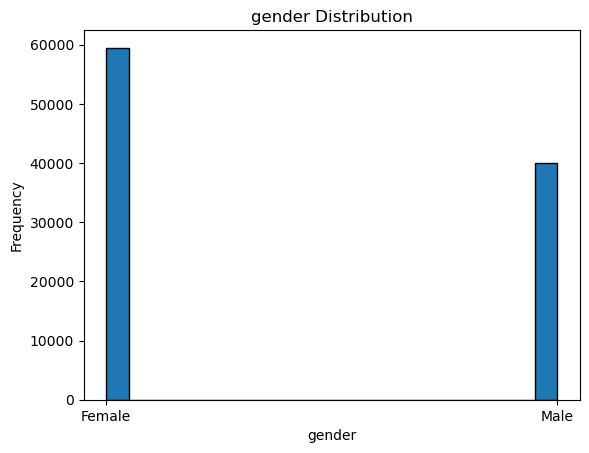

In [37]:
# Gender histogram
plt.hist(Shopping_data['gender'], bins=20, edgecolor='black')
plt.title('gender Distribution')
plt.xlabel('gender')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

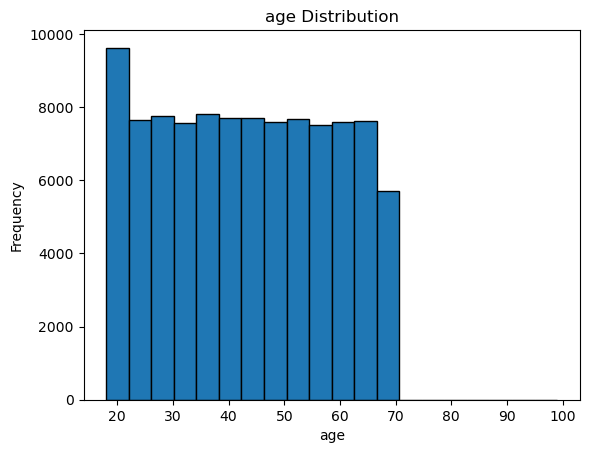

In [38]:
# Gender histogram
plt.hist(Shopping_data['age'], bins=20, edgecolor='black')
plt.title('age Distribution')
plt.xlabel('age')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

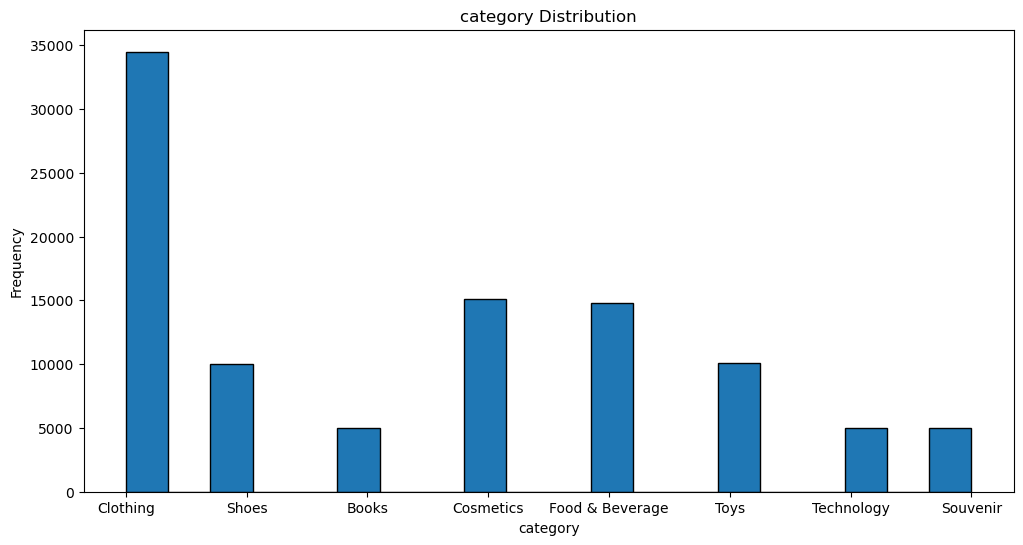

In [39]:
plt.figure(figsize=(12, 6))
plt.hist(Shopping_data['category'], bins=20, edgecolor='black')
plt.title('category Distribution')
plt.xlabel('category')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

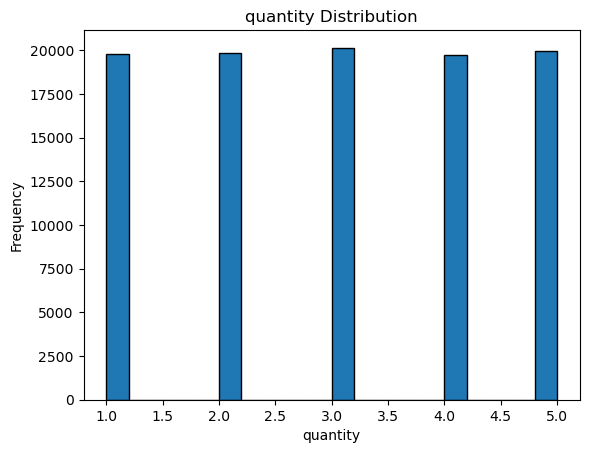

In [40]:
plt.hist(Shopping_data['quantity'], bins=20, edgecolor='black')
plt.title('quantity Distribution')
plt.xlabel('quantity')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

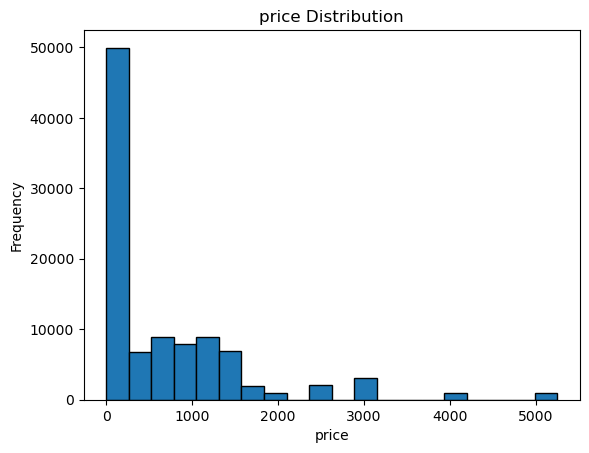

In [41]:
plt.hist(Shopping_data['price'], bins=20, edgecolor='black')
plt.title('price Distribution')
plt.xlabel('price')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

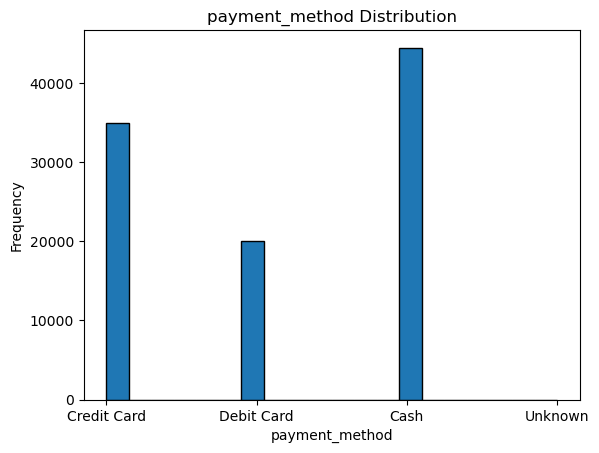

In [42]:
plt.hist(Shopping_data['payment_method'], bins=20, edgecolor='black')
plt.title('payment_method Distribution')
plt.xlabel('payment_method')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

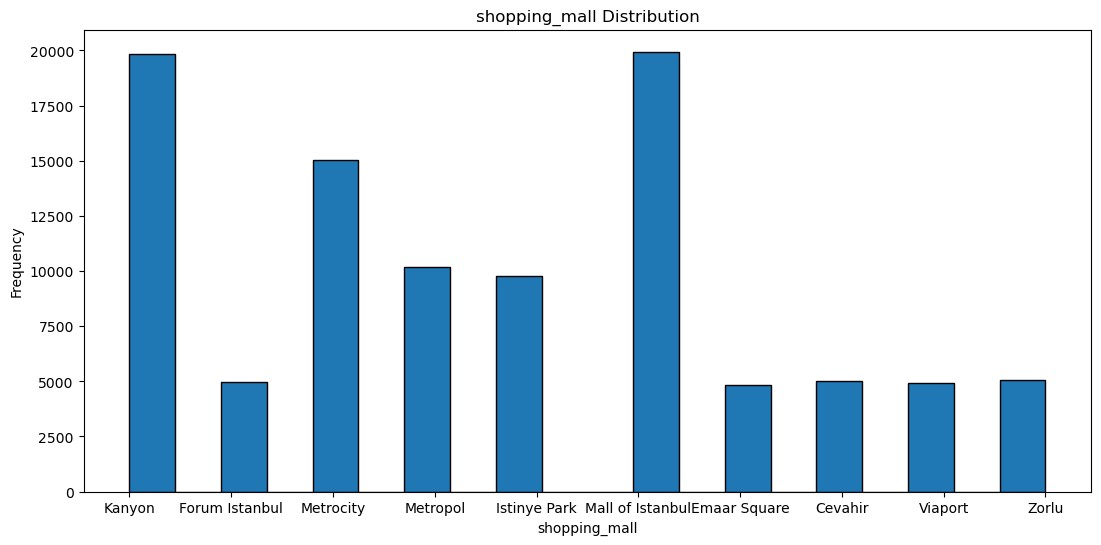

In [43]:
plt.figure(figsize=(13, 6))
plt.hist(Shopping_data['shopping_mall'], bins=20, edgecolor='black')
plt.title('shopping_mall Distribution')
plt.xlabel('shopping_mall')
plt.ylabel('Frequency')

**Find and fix outliers**

Text(0, 0.5, 'age)')

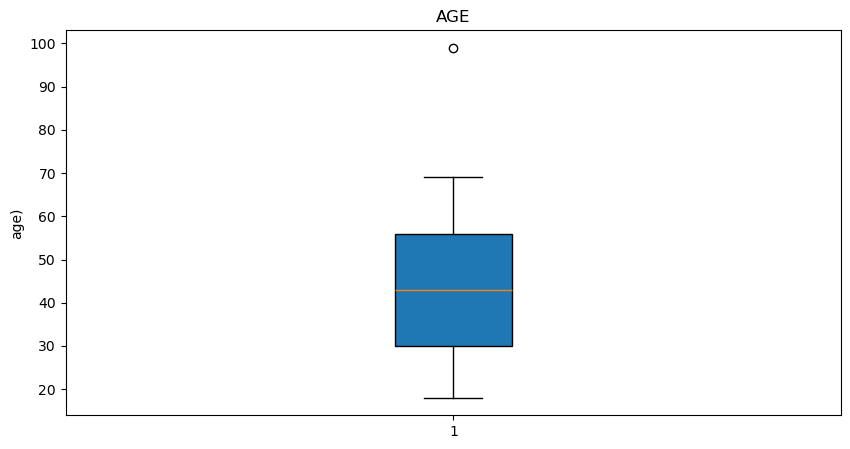

In [44]:
plt.figure(figsize = (10,5))
plt.boxplot(Shopping_data['age'], patch_artist=True)
plt.title('AGE')
plt.ylabel('age)')

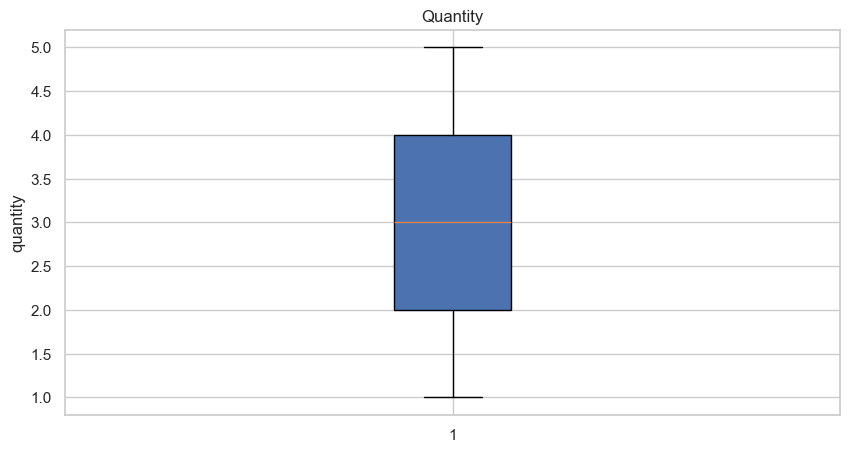

In [60]:
plt.figure(figsize = (10,5))
plt.boxplot(Shopping_data['quantity'], patch_artist=True)
plt.title('Quantity')
plt.ylabel('quantity')
plt.show()


In [ ]:
# it shows there is no outliers

**Checking outlier price per catagory**

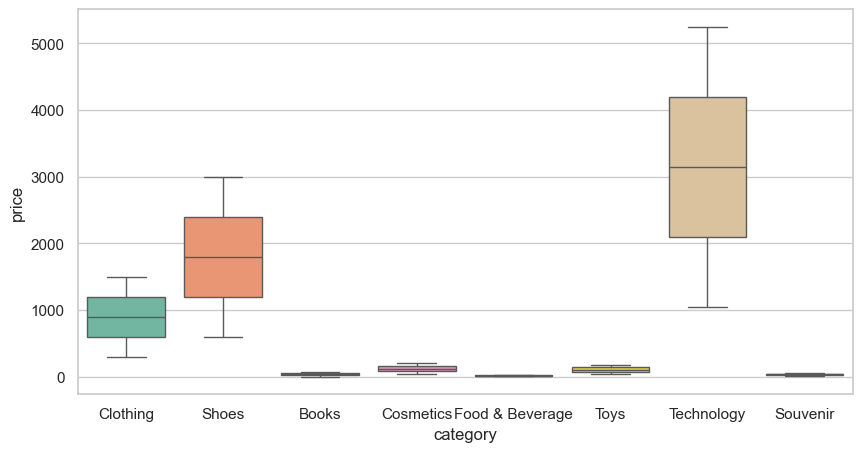

In [45]:
plt.figure(figsize=(10, 5)) 
sns.set(style="whitegrid")
sns.boxplot(x="category", y="price", data=Shopping_data, hue="category", palette="Set2", dodge=False)
plt.legend([],[], frameon=False)  #To make it more visible I took help from chat.gpt to make it color full
plt.show()
           

**Analysis**

In [46]:
#Based on your analysis, which customer segments/categories should the shopping mall target for marketing campaigns?

In [47]:
Category_by_Quantity = Shopping_data.groupby("category")["quantity"].count()
Category_by_Quantity

category
Books               4982
Clothing           34486
Cosmetics          15096
Food & Beverage    14777
Shoes              10035
Souvenir            4999
Technology          4996
Toys               10088
Name: quantity, dtype: int64

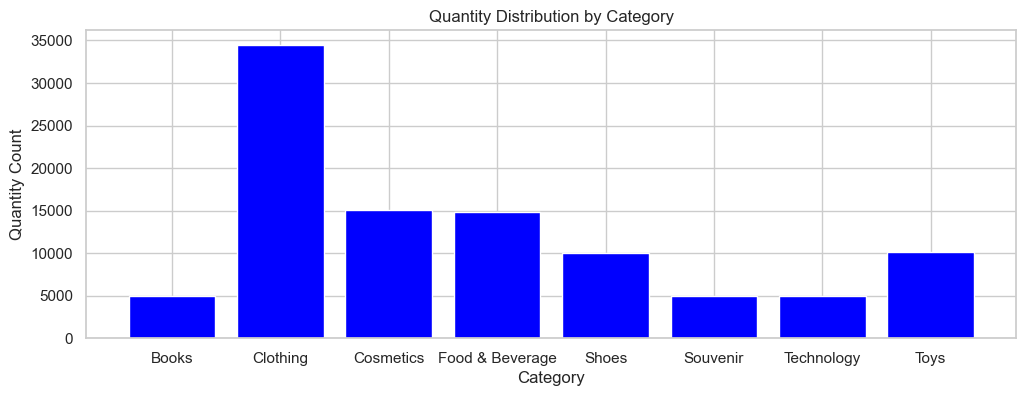

In [48]:
# Category_by_Quantity histogram
plt.figure(figsize=(12, 4))
plt.bar(Category_by_Quantity.index, Category_by_Quantity.values, color='blue')
plt.title("Quantity Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Quantity Count")

plt.show()

Based on the provided bar chart, the shopping mall should consider targeting the following customer segments/categories for its marketing campaigns:

1.Clothing: This category has the highest quantity count, indicating a significant demand for clothing items.
2.Cosmetics: While it's not as high as clothing, the cosmetics category still shows a substantial interest among shoppers.
3.Food & Beverage: This category represents a consistent demand, likely due to the need for food and drink options within the shopping mall.

In [49]:
#Create a box plot to compare the distribution of spending scores between male and female customers.
#What can you infer from the box plot about the spending behaviour of different genders?

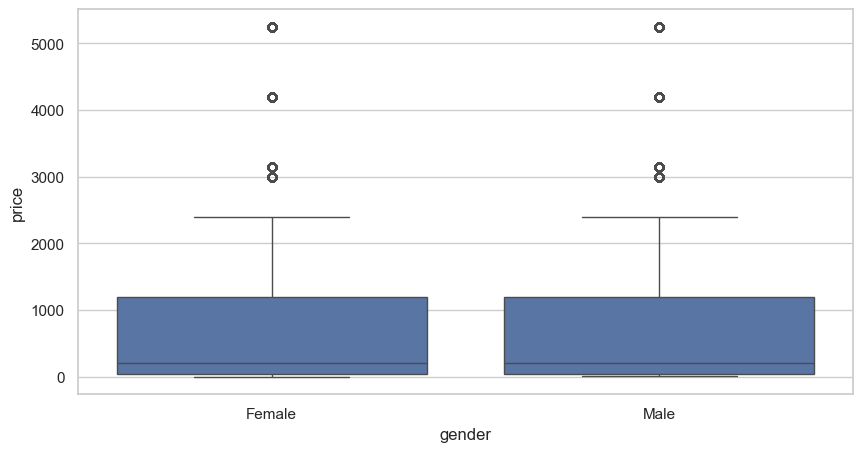

In [50]:
plt.figure(figsize=(10, 5)) 
sns.set(style="whitegrid")
sns.boxplot(x="gender", y="price", data=Shopping_data) 
plt.show()

There is no significant difference in the typical spending amount between male and female customers.

In [51]:
#Create a scatter plot to visualise the relationship between age and spending. What insights can you derive from this visualization?
#Is there a correlation between age and spending?

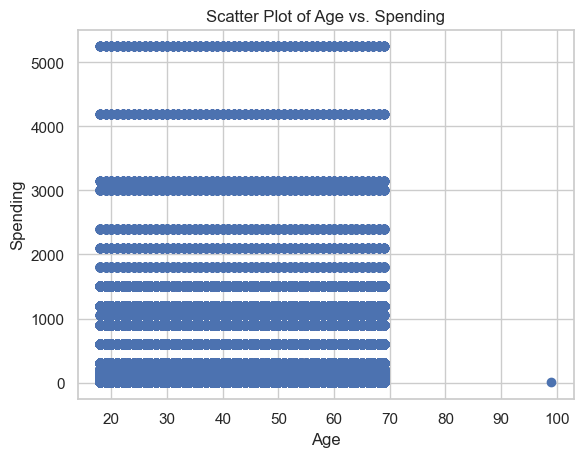

In [52]:
plt.scatter(Shopping_data['age'], Shopping_data['price'])
plt.title('Scatter Plot of Age vs. Spending')
plt.xlabel('Age')
plt.ylabel('Spending')
plt.show()

In [53]:
correlation = Shopping_data['age'].corr(Shopping_data['price'])
print(f'Correlation between Age and Spending: {correlation}')

Correlation between Age and Spending: 0.0016644852710545053


Based on the provided scatter plot, there appears to be a weak positive correlation between age and spending. while there is a slight tendency for spending to increase with age, it’s not a consistent or strong trend. Therefore, age should be considered just one of many factors when analyzing or predicting spending behavior.

**Recommendation:**

In [54]:
#Sales by Payment Method:

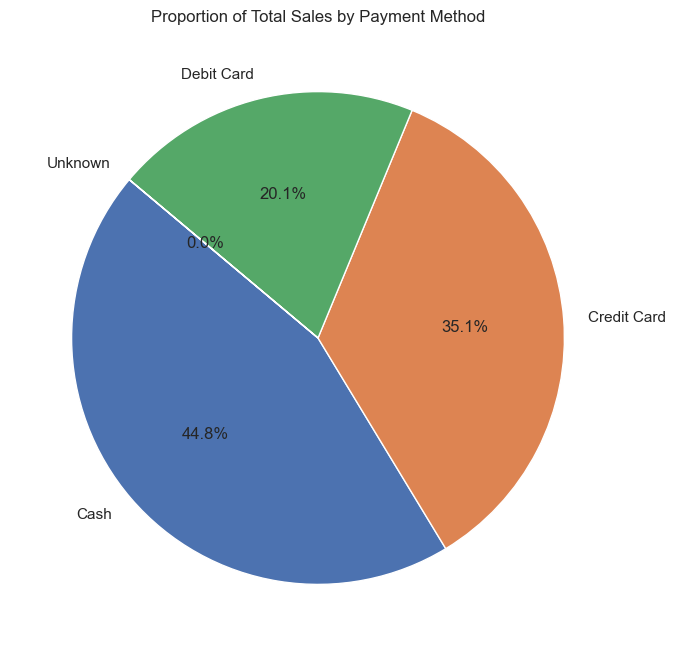

In [55]:
payment_sales = Shopping_data.groupby('payment_method')['price'].sum().reset_index()
plt.figure(figsize=(8, 8))
plt.pie(payment_sales['price'], labels=payment_sales['payment_method'], autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Total Sales by Payment Method')
plt.show() #used pie syntax from chat.gpt

Cash is still the top choice for payments, making up 44.8% of transactions, with credit cards close behind at 35.1%. Debit cards also play a significant role, covering 20.1% of sales, and unknown payments are practically nonexistent. This shows that traditional payment methods are still strong, but there’s a noticeable shift towards digital payments. To improve, keep cash and credit card options, encourage debit card use with some incentives, look into any unknown payments to fix data issues, and stay on top of new payment trends to keep up with customer preferences.

In [56]:
#Sales Trend Over Time:

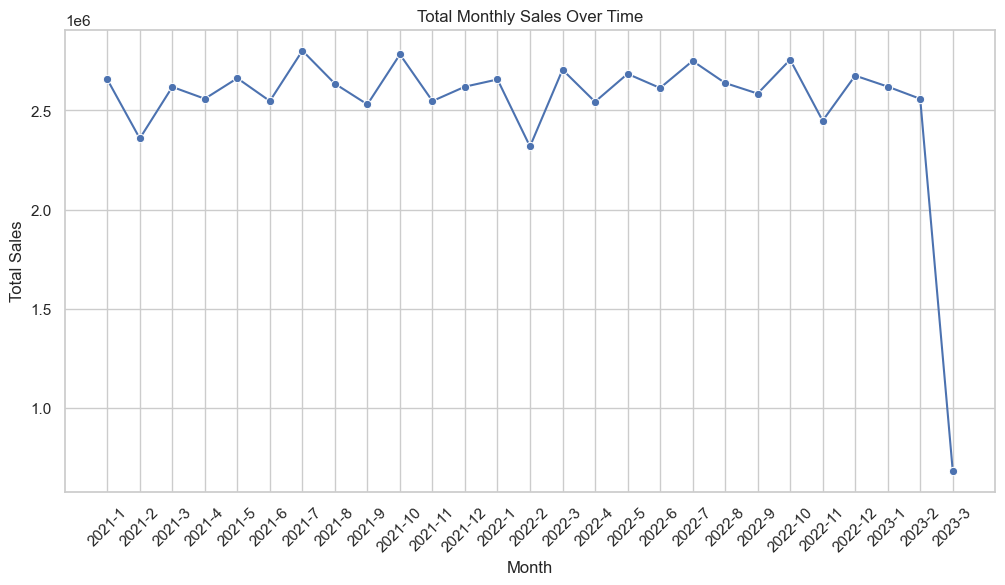

In [57]:
monthly_sales = Shopping_data.groupby(['Year', 'Month'])['price'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str)
plt.figure(figsize=(12, 6))
sns.lineplot(x='YearMonth', y='price', data=monthly_sales, marker='o')
plt.title('Total Monthly Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()


Based on the analysis of the line chart for total monthly sales, we observe a steady increase in sales from early 2021 until September 2021, indicating positive growth. Seasonal fluctuations are apparent throughout the year, suggesting that factors like holidays or events influenced sales patterns. However, a significant decline in March 2023 highlights a major disruption that impacted sales. To address these insights, it's crucial to investigate the cause of the 2023 sales drop, identify and leverage seasonal trends for better planning, and develop a strategic growth plan. Additionally, continuous monitoring of key performance indicators will help in adapting to market changes and driving future growth.